In [1]:
import warnings
warnings.filterwarnings("ignore")
from torch import multiprocessing
import torch.nn as nn
    

from collections import defaultdict

import matplotlib.pyplot as plt
import torch
from tensordict.nn import TensorDictModule
from tensordict.nn.distributions import NormalParamExtractor
from torch import nn
from torchrl.collectors import SyncDataCollector
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.envs import (Compose, DoubleToFloat, ObservationNorm, StepCounter,
                          TransformedEnv)
from torchrl.envs.libs.gym import GymEnv
from torchrl.envs.utils import check_env_specs, ExplorationType, set_exploration_type
from torchrl.modules import ProbabilisticActor, TanhNormal, ValueOperator
from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.value import GAE
from tqdm import tqdm

In [2]:
import gymnasium as gym

[
    print(game_env)
    for game_env in list(gym.envs.registry.keys())
];

CartPole-v0
CartPole-v1
MountainCar-v0
MountainCarContinuous-v0
Pendulum-v1
Acrobot-v1
phys2d/CartPole-v0
phys2d/CartPole-v1
phys2d/Pendulum-v0
LunarLander-v3
LunarLanderContinuous-v3
BipedalWalker-v3
BipedalWalkerHardcore-v3
CarRacing-v3
Blackjack-v1
FrozenLake-v1
FrozenLake8x8-v1
CliffWalking-v1
CliffWalkingSlippery-v1
Taxi-v3
tabular/Blackjack-v0
tabular/CliffWalking-v0
Reacher-v2
Reacher-v4
Reacher-v5
Pusher-v2
Pusher-v4
Pusher-v5
InvertedPendulum-v2
InvertedPendulum-v4
InvertedPendulum-v5
InvertedDoublePendulum-v2
InvertedDoublePendulum-v4
InvertedDoublePendulum-v5
HalfCheetah-v2
HalfCheetah-v3
HalfCheetah-v4
HalfCheetah-v5
Hopper-v2
Hopper-v3
Hopper-v4
Hopper-v5
Swimmer-v2
Swimmer-v3
Swimmer-v4
Swimmer-v5
Walker2d-v2
Walker2d-v3
Walker2d-v4
Walker2d-v5
Ant-v2
Ant-v3
Ant-v4
Ant-v5
Humanoid-v2
Humanoid-v3
Humanoid-v4
Humanoid-v5
HumanoidStandup-v2
HumanoidStandup-v4
HumanoidStandup-v5
GymV21Environment-v0
GymV26Environment-v0


In [3]:
from torchrl.envs import (Compose, DoubleToFloat, ObservationNorm, StepCounter,
                          TransformedEnv, set_exploration_type)

dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(dev)

base_env = GymEnv("InvertedDoublePendulum-v4", device=dev)
env = TransformedEnv(
    base_env, 
    Compose(
        # normalize observations
        ObservationNorm(in_keys=["observation"]),
        DoubleToFloat(),
        StepCounter(),
    )
)
env.transform[0].init_stats(num_iter=1000, reduce_dim=0, cat_dim=0)
obsv=  env.reset()
obsv

cuda


TensorDict(
    fields={
        done: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        observation: Tensor(shape=torch.Size([11]), device=cuda:0, dtype=torch.float32, is_shared=True),
        step_count: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.int64, is_shared=True),
        terminated: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        truncated: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.bool, is_shared=True)},
    batch_size=torch.Size([]),
    device=cuda:0,
    is_shared=True)

In [4]:
print("observation_spec:", env.observation_spec)
print("reward_spec:", env.reward_spec)
print("input_spec:", env.input_spec)
print("action_spec (as defined by input_spec):", env.action_spec)

observation_spec: Composite(
    observation: UnboundedContinuous(
        shape=torch.Size([11]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([11]), device=cuda:0, dtype=torch.float32, contiguous=True),
            high=Tensor(shape=torch.Size([11]), device=cuda:0, dtype=torch.float32, contiguous=True)),
        device=cuda:0,
        dtype=torch.float32,
        domain=continuous),
    step_count: BoundedDiscrete(
        shape=torch.Size([1]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.int64, contiguous=True),
            high=Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.int64, contiguous=True)),
        device=cuda:0,
        dtype=torch.int64,
        domain=discrete),
    device=cuda:0,
    shape=torch.Size([]),
    data_cls=None)
reward_spec: UnboundedContinuous(
    shape=torch.Size([1]),
    space=ContinuousBox(
        low=Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.fl

In [5]:
from torchrl.envs.utils import check_env_specs

check_env_specs(env)

2026-05-21 21:16:25,666 [torchrl][INFO]    check_env_specs succeeded! [END]


In [6]:
from torchrl.objectives.value import TD0Estimator
import torch.distributions as d
from torchrl.modules.tensordict_module.common import TensorDictModule
from torchrl.modules import NormalParamExtractor


hidden_features = 256

# policy fn
policy_net_raw = nn.Sequential(*[
    nn.LazyLinear(hidden_features),
    nn.Tanh(),
    nn.LazyLinear(hidden_features),
    nn.Tanh(),
    nn.LazyLinear(2*env.action_spec.shape[-1]),    
    NormalParamExtractor()
]).to(dev)

policy_module = TensorDictModule(
    policy_net_raw,
    in_keys=['observation'],
    out_keys=['loc', 'scale'],
)
# policy_net = nn.Sequential(*[
#     policy_module,
# ])
actor = ProbabilisticActor(
    module=policy_module,
    in_keys=['loc', 'scale'],
    out_keys=['action'],
    distribution_class=d.Normal,
    return_log_prob=True,
    spec=env.action_spec
)


critic_net = nn.Sequential(*[
    nn.LazyLinear(hidden_features),
    nn.Tanh(),
    nn.LazyLinear(hidden_features),
    nn.Tanh(),
    nn.LazyLinear(1)
]).to(dev)

value_module = TensorDictModule(
    module=critic_net,
    in_keys=['observation'],
    out_keys=['state_value']
)

In [7]:
clip_epsilon = 0.2
entropy_eps = 1e-3


loss_fn = ClipPPOLoss(
    actor_network=actor,
    critic_network=value_module,
        clip_epsilon=clip_epsilon,
    entropy_bonus=bool(entropy_eps),
    entropy_coeff=entropy_eps,
    # these keys match by default but we set this for completeness
    critic_coeff=1.0,
    loss_critic_type="smooth_l1",
)
loss_fn

ClipPPOLoss()

In [8]:
from torchrl.objectives import ValueEstimators

loss_fn.make_value_estimator(
    ValueEstimators.TD0,
    gamma=0.99
)

In [9]:
# data collector

from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.collectors import Collector
from torchrl.envs.utils import ExplorationType

frames_per_batch = 5_000
total_frames = 10_000

replay_buf = ReplayBuffer(
    storage=LazyTensorStorage(max_size=frames_per_batch),
    sampler=SamplerWithoutReplacement()
)

collector = Collector(
    env,
    actor,
    frames_per_batch=frames_per_batch,
    total_frames=-1,
    device=dev,
    # replay_buffer=replay_buf,
    split_trajs=False,
    exploration_type=ExplorationType.RANDOM, 
    
)
collector

Collector(
    env=TransformedEnv(
        env=GymEnv(env=InvertedDoublePendulum-v4, batch_size=torch.Size([]), device=cuda:0),
        transform=Compose(
                ObservationNorm(keys=['observation']),
                DoubleToFloat(in_keys=['observation'], out_keys=['observation'], in_keys_inv=[], out_keys_inv=[]),
                StepCounter(keys=[]))),
    policy=ProbabilisticActor(
        module=ModuleList(
          (0): TensorDictModule(
              module=Sequential(
                (0): Linear(in_features=11, out_features=256, bias=True)
                (1): Tanh()
                (2): Linear(in_features=256, out_features=256, bias=True)
                (3): Tanh()
                (4): Linear(in_features=256, out_features=2, bias=True)
                (5): NormalParamExtractor(
                  (scale_mapping): biased_softplus()
                )
              ),
              device=cuda:0,
              in_keys=['observation'],
              out_keys=['loc', 'scale

In [10]:
with torch.no_grad():
    dummy_data = env.reset()
    obsv = dummy_data['observation']
    obsv = obsv.to(dev)
    
    policy_net_raw(obsv)
    critic_net(obsv)

In [11]:
for tensordict_data in collector:
    print(tensordict_data)
    break

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([5000, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
        action_log_prob: Tensor(shape=torch.Size([5000, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
        collector: TensorDict(
            fields={
                traj_ids: Tensor(shape=torch.Size([5000]), device=cuda:0, dtype=torch.int64, is_shared=True)},
            batch_size=torch.Size([5000]),
            device=cuda:0,
            is_shared=True),
        done: Tensor(shape=torch.Size([5000, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        loc: Tensor(shape=torch.Size([5000, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([5000, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
                observation: Tensor(shape=torch.Size([5000, 11]), device=cuda:0, dtype=torch.float32, is_shared=True),
                re

In [12]:
# optimizer

from torch.optim import AdamW

optim_actor = AdamW(actor.parameters(), lr=3e-4)
optim_critic = AdamW(critic_net.parameters(), lr=3e-4)

In [13]:
BATCH_SIZE=712
TRAIN_EPOCHS = 30
TEST_EPS = 5
TEST_MAX_STEP_SIZE = 1000
trunc = False

train_losses, objective_losses, critic_losses, entropy_losses = [], [], [], []
train_rewards = []
test_returns_all, test_step_counts_all = [], []

# train
for ep in range(TRAIN_EPOCHS):
    actor.train()
    critic_net.train()
    
    tensordict_data = next(iter(collector))
    replay_buf.extend(tensordict_data)

    loss_batch = 0
    objective_loss, critic_loss, entropy_loss = 0,0,0
    for _ in range(10):
        batch = replay_buf.sample(BATCH_SIZE)
        batch = batch.to(dev)
        
        loss_val = loss_fn(batch)
        loss = loss_val['loss_objective'] + loss_val['loss_critic'] + loss_val['loss_entropy']
        loss_batch += loss

        objective_loss += loss_val['loss_objective']
        critic_loss += loss_val['loss_critic']
        entropy_loss += loss_val['loss_entropy']

    torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
    torch.nn.utils.clip_grad_norm_(critic_net.parameters(), 1.0)

    optim_actor.zero_grad()
    optim_critic.zero_grad()

    loss_batch.backward()        
    
    
    optim_actor.step()
    optim_critic.step()

    train_losses.append(loss_batch.item())
    objective_losses.append(objective_loss.item())
    critic_losses.append(critic_loss.item())
    entropy_losses.append(entropy_loss.item())
    
    avg_reward = tensordict_data["next", "reward"].mean().item()
    train_rewards.append(avg_reward)

    # eval
    test_reward, test_step_c = 0,0
    actor.eval()
    with set_exploration_type(ExplorationType.DETERMINISTIC), torch.inference_mode():
        test_returns, test_step_cs = [],[]
        for _ in range(TEST_EPS):
            tensordict_data =env.rollout(TEST_MAX_STEP_SIZE, policy=actor)
    
            test_return = tensordict_data["next", "reward"].sum().item()
            test_step_c = tensordict_data["next",'step_count'].max().item()

            test_returns.append(test_return)
            test_step_cs.append(test_step_c)       
        

    test_return = sum(test_returns) / len(test_returns)
    test_step_count = sum(test_step_cs) / len(test_step_cs)

    test_returns_all.append(test_return)
    test_step_counts_all.append(test_step_count)
    
    print(f'epoch: {ep} | train step_count: {tensordict_data['step_count'].max().item()} | loss: {loss_batch.item():.5f} | loss_objective: {objective_loss.item():.5f} | loss_critic: {critic_loss.item():.5f} | loss_entropy: {entropy_loss.item():.5f} | test step_count: {test_step_count:.5f} | test return: {test_return:.5f} | reward: {avg_reward:.5f}')

2026-05-17 17:22:59,027 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([5000]) shape [END]
epoch: 0 | train step_count: 10 | loss: -5.01416 | loss_objective: -90.86689 | loss_critic: 85.86690 | loss_entropy: -0.01417 | test step_count: 9.20000 | test return: 84.26237 | reward: 9.07945
epoch: 1 | train step_count: 8 | loss: -5.01418 | loss_objective: -90.64018 | loss_critic: 85.64019 | loss_entropy: -0.01418 | test step_count: 9.40000 | test return: 86.45950 | reward: 9.07795
epoch: 2 | train step_count: 7 | loss: -5.01389 | loss_objective: -90.34975 | loss_critic: 85.34975 | loss_entropy: -0.01389 | test step_count: 9.00000 | test return: 82.57462 | reward: 9.07422
epoch: 3 | train step_count: 8 | loss: -5.01387 | loss_objective: -90.31416 | loss_critic: 85.31417 | loss_entropy: -0.01387 | test step_count: 9.00000 | test return: 82.54474 | reward: 9.06847
epoch: 4 | train step_count: 7 | loss: -5.01377 | loss_objective: -90.01030 | loss_critic: 85.01031 | loss_entropy

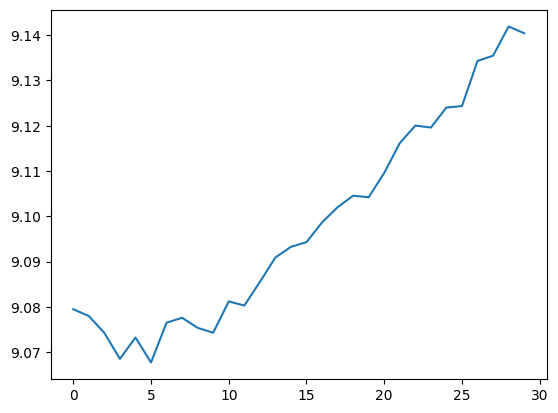

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_rewards)

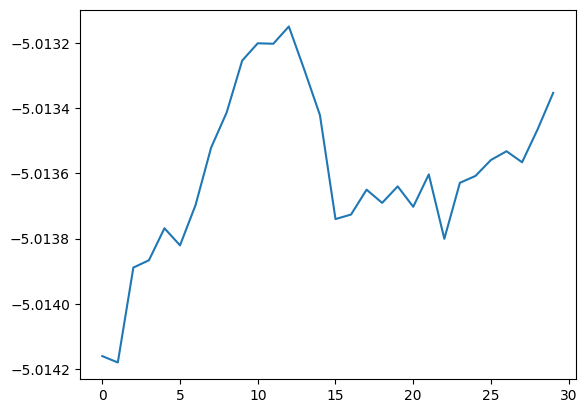

In [16]:
import matplotlib.pyplot as plt

plt.plot(train_losses)

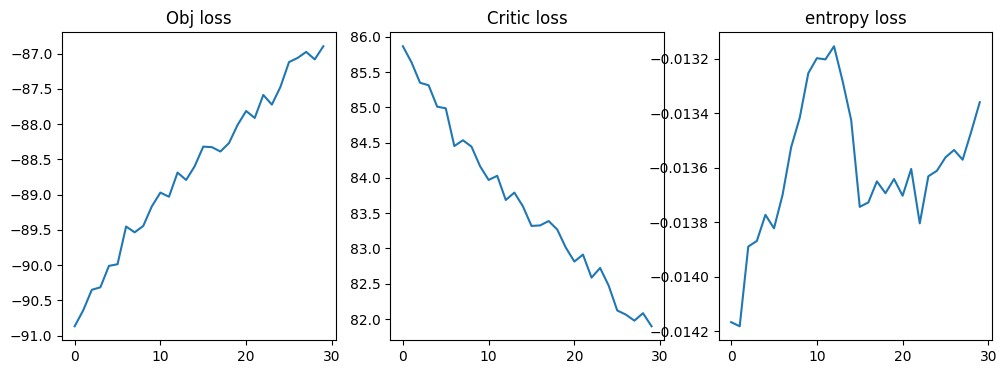

In [17]:
fig = plt.figure(figsize=(12, 4))

import numpy as np

t = np.arange(0, TRAIN_EPOCHS)

ax1 = fig.add_subplot(1, 3,1)
ax2 = fig.add_subplot(1, 3,2)
ax3 = fig.add_subplot(1, 3,3)

ax1.plot(t, objective_losses)
ax2.plot(t,critic_losses)
ax3.plot(t,entropy_losses)

ax1.set_title('Obj loss')
ax2.set_title('Critic loss')
ax3.set_title('entropy loss')
plt.show()

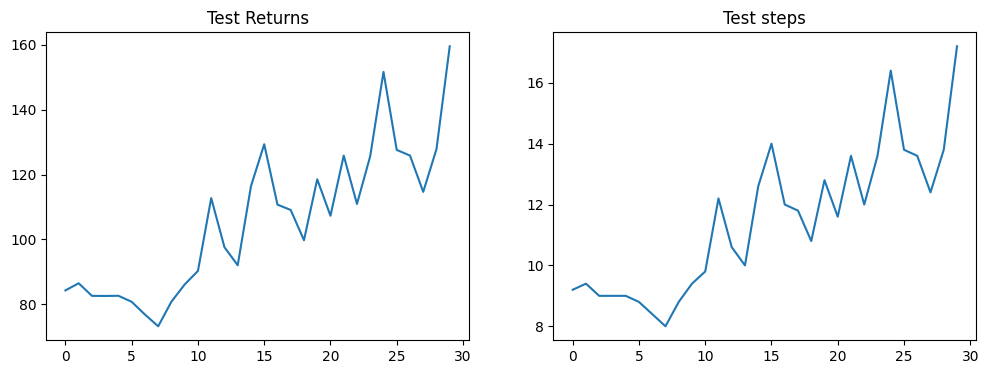

In [18]:
fig = plt.figure(figsize=(12, 4))

import numpy as np

t = np.arange(0, len(test_returns_all))

ax1 = fig.add_subplot(1, 2,1)
ax2 = fig.add_subplot(1, 2,2)

ax1.plot(t, test_returns_all)
ax2.plot(t,test_step_counts_all)

ax1.set_title('Test Returns')
ax2.set_title('Test steps')
plt.show()

In [13]:
# test

with torch.no_grad():
    obsv = env.reset()
    #  ...

In [ ]:

env.close()